# 02 · Canonical analysis & slides — FC reconfiguration predicts working memory

**Authors:** Jaime Alonso Pineda Moreno (canonical assembly) · Goutham Arcod (FC fingerprint &
segregation method) · Valeria Moraga · Kerem Akyurt · Arefeh Lali Dehaghi — *The Gammas (Group 1)*
· **Date:** 2026-07-21 · **Status:** for team review (pipeline/ requires one reviewer)

## Question

> Does functional-connectivity **reconfiguration** from low (0-back) to high (2-back) working-memory
> load predict individual WM performance in **unseen** subjects — and is that signal specific to
> connectivity?

## What this notebook is

The single **evidence notebook** for the W3D5 presentation: it runs from a clean kernel, top to
bottom, and reproduces only the claims and figures we will present. It does **not** open new analyses.
Every number below is computed here and surfaced in a code output or the final summary table; the
prose states method and meaning, not hand-typed figures.

Method and code are the team's, reused verbatim through the shared read-only data layer
(`datasets.py` → `preprocessing.py` → `connectivity.py` → `evaluation.py`). Source sandbox notebooks,
each the reviewed origin of one block here:

| Block | Origin | What it contributed |
|---|---|---|
| Main prediction, d′, direction | [`04_goutham_pipeline_on_B`](../sandbox/jaime/04_goutham_pipeline_on_B.ipynb) | reproduction gate + canonical CV numbers |
| B→A external transfer | [`05_dataset_A_external_validation`](../sandbox/jaime/05_dataset_A_external_validation.ipynb) | leakage-free transfer design |
| Method comparison & incrementals | [`08_activation_vs_reconfiguration`](../sandbox/jaime/08_activation_vs_reconfiguration.ipynb) | activation baseline, nested ΔR² |
| Goutham-pipeline reconciliation | [`09_goutham_pipeline_replication`](../sandbox/jaime/09_goutham_pipeline_replication.ipynb) | segregation direction, number reconciliation |

**Official abstract for W3D5:** the corrected 21 Jul draft in
[`manuscript/abstract.md`](../manuscript/abstract.md) — the presentation-facing text, aligned with the
numbers computed here. The submitted 20 Jul version is kept in the same file as historical record
(sent, not graded by NMA). §10 traces the alignment; the abstract's closing claim is exactly what this
notebook's evidence supports.

**In scope:** cohort B (336 subj, 360 ROIs, 12 networks); 0/2-back extraction with a 4 s HRF delay;
per-condition FC and the 78-feature reconfiguration fingerprint; RidgeCV with repeated CV; B→A
transfer on non-overlapping subjects; comparison of 0-back FC, reconfiguration FC and regional
activation, with incremental tests; the group-level segregation direction, separated from the weak
individual association; the aggregate static figures for the slides.

**Explicitly out of scope** (not new experiments here): FCM / K-Means clustering on activation,
tangent-space FC, and any new graph metrics. FCM is exploratory only (weak clustering, near-maximum
entropy — [nb09](../sandbox/jaime/09_goutham_pipeline_replication.ipynb)) and is kept out of the main
analysis. Data access follows `GAMMAS_DATA_DIR` and the contract in
[`data/README.md`](../data/README.md); no subject identifiers are shown or saved — counts only.

## 1 · Setup

Locate the repo root from wherever the notebook runs, put the shared A/B layer first on the path
(so `import datasets` is ours), resolve the data dir from `GAMMAS_DATA_DIR`, and fix the seeds and
permutation count. The run is timed; the environment is recorded at the end (§10).

In [1]:
import os, sys, time, platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, norm, ttest_rel
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from nilearn import plotting                          # static glass-brain rendering (bundled MNI template)


def find_repo_root(start: Path) -> Path:
    """Nearest ancestor holding requirements.txt and sandbox/ — the repo root."""
    for p in (start, *start.parents):
        if (p / "requirements.txt").exists() and (p / "sandbox").is_dir():
            return p
    raise FileNotFoundError("Repo root not found — run inside a clone of The-Gammas.")

ROOT = find_repo_root(Path.cwd())
SHARED = ROOT / "sandbox" / "jaime"                 # shared A/B layer — imported read-only
sys.path.insert(0, str(SHARED))
DATA = Path(os.environ.get("GAMMAS_DATA_DIR", ROOT / "data"))

import datasets as ds, preprocessing as pp, connectivity as cn, evaluation as ev

# --- fixed analysis constants (shared by every block) ---
DELAY = 4.0                                         # HRF shift (s); tracks the BOLD response
SEED = 42                                           # single-split / display seed
N_SEEDS = 20                                        # repeated-CV partitions -> stable effect size
N_PERM = int(os.environ.get("GAMMAS_NPERM", "1000"))# permutation null (p floor 1/(N_PERM+1))
N_BOOT = 2000
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "figure.autolayout": False})

T_START = time.time()
B, A = ds.spec_b(DATA), ds.spec_a(DATA)
print("repo:", ROOT.name, "| data:", DATA)
print("cohorts:", B.name, "|", A.name)

repo: the-gammas | data: ../data
cohorts: Finalist B (339 subj, +resting-state) | Finalist A (100 subj, task-only)


## 2 · Shared modelling helpers

The estimator is the team's `evaluation.ridge_pipeline` — `StandardScaler` + `RidgeCV`, wrapped so the
scaler and the ridge penalty are **fit on training rows only** inside every fold. Standardisation
therefore always happens *within* each fold, never before the split. All comparisons below change
only the features fed to this one estimator; the permutation null refits the whole pipeline on
permuted labels (a proper model-based null).

In [2]:
def cv_predict(X, y, seed=SEED):
    """Leakage-free 5-fold out-of-fold predictions (scaler + ridge fit in-fold)."""
    return cross_val_predict(ev.ridge_pipeline(), X, y, cv=KFold(5, shuffle=True, random_state=seed))

def repeated_cv_r(X, y, n_seeds=N_SEEDS):
    """Mean, sd of out-of-fold Pearson r over n_seeds CV partitions — the reported effect size."""
    rs = np.array([pearsonr(cv_predict(X, y, s), y)[0] for s in range(n_seeds)])
    return float(rs.mean()), float(rs.std())

def repeated_cv_r2(X, y, n_seeds=N_SEEDS):
    """Mean out-of-fold R^2 over n_seeds partitions."""
    return float(np.mean([r2_score(y, cv_predict(X, y, s)) for s in range(n_seeds)]))

def permutation_null(X, y, obs_r, n=N_PERM, seed=0):
    """One-sided p and null distribution; refits the pipeline on each permuted target.

    p uses the (#exceed + 1)/(n + 1) estimator (Phipson & Smyth 2010): a Monte-Carlo p can
    never be 0, and its floor 1/(n+1) counts the observed statistic among the permutations.
    """
    rng = np.random.default_rng(seed)
    null = np.empty(n)
    for i in range(n):
        yp = rng.permutation(y)
        null[i] = pearsonr(cv_predict(X, yp), yp)[0]
    p = ((null >= obs_r).sum() + 1) / (n + 1)
    return float(p), null

def incremental_r2(full, base, y, n_seeds=N_SEEDS):
    """Paired incremental out-of-fold R^2 (full minus base) on identical folds, per seed."""
    d = np.array([r2_score(y, cv_predict(full, y, s)) - r2_score(y, cv_predict(base, y, s))
                  for s in range(n_seeds)])
    return float(d.mean()), float(d.std())

def cross_run_r(F_run0, F_run1, y, seed=SEED):
    """Train on one run's features (train subjects), predict the OTHER run of held-out subjects."""
    def one(Fa, Fb):
        pred = np.zeros_like(y, float)
        for tr, te in KFold(5, shuffle=True, random_state=seed).split(Fa):
            sc = StandardScaler().fit(Fa[tr])
            m = ev.ridge_pipeline().fit(Fa[tr], y[tr])
            pred[te] = m.predict(Fb[te])           # held-out subjects, features from the other run
        return pearsonr(pred, y)[0]
    return float((one(F_run0, F_run1) + one(F_run1, F_run0)) / 2)

def between_run_reliability(F0, F1):
    """Fisher-averaged per-feature test-retest r across subjects (LR vs RL)."""
    rr = [pearsonr(F0[:, j], F1[:, j])[0] for j in range(F0.shape[1])]
    return float(np.tanh(np.nanmean(np.arctanh(np.clip(rr, -0.999, 0.999)))))
print("helpers ready")

helpers ready


## 3 · Cohort B — dimension & participant checks

Aggregate QC via `evaluation.validate_dataset`, then explicit `assert`s on the three numbers the
analysis rests on: **336** analytic participants, **360** Glasser ROIs, **12** Cole-Anticevic
networks. Counts only — no identifiers. (Three of the 339 task subjects lack complete 2-back
behaviour and are dropped by `datasets.load_subjects`.)

In [3]:
qc = ev.validate_dataset(B)
qc_view = pd.Series({k: qc[k] for k in (
    "dataset", "loader", "n_subjects_total", "n_subjects_analytic",
    "wm_run_shape", "frames_0back_concat", "frames_2back_concat", "cond_overlap",
    "n_parcels", "n_networks", "acc_2bk_n", "acc_2bk_mean", "behaviour_missing_2bk")})

assert qc["n_subjects_analytic"] == 336, qc["n_subjects_analytic"]
assert qc["n_parcels"] == 360, qc["n_parcels"]
assert qc["n_networks"] == 12, qc["n_networks"]
assert qc["cond_overlap"] == 0, "0-back and 2-back frames must not overlap"
qc_view

Out[3]: 
dataset                  Finalist B (339 subj, +resting-state)
loader                                                load_hcp
n_subjects_total                                           339
n_subjects_analytic                                        336
wm_run_shape                                        (360, 405)
frames_0back_concat                                        312
frames_2back_concat                                        312
cond_overlap                                                 0
n_parcels                                                  360
n_networks                                                  12
acc_2bk_n                                                  336
acc_2bk_mean                                             0.849
behaviour_missing_2bk                                        3
dtype: object


dataset                  Finalist B (339 subj, +resting-state)
loader                                                load_hcp
n_subjects_total                                           339
n_subjects_analytic                                        336
wm_run_shape                                        (360, 405)
frames_0back_concat                                        312
frames_2back_concat                                        312
cond_overlap                                                 0
n_parcels                                                  360
n_networks                                                  12
acc_2bk_n                                                  336
acc_2bk_mean                                             0.849
behaviour_missing_2bk                                        3
dtype: object

## 4 · Feature extraction — 0/2-back FC and the 78-feature reconfiguration fingerprint

One pass over cohort B, both runs per subject, from the **same 4 s-delayed** condition frames
(`preprocessing.condition_frames(..., delay=4.0)`). Per subject we build, per condition:

- the **FC fingerprint** (78) — within/between-network correlation means over the 12 networks
  (`connectivity.network_fingerprint`), and its **reconfiguration** = 2-back − 0-back;
- the **regional activation** (360) — mean BOLD per ROI (for the §7 baseline);
- a **DVARS** motion proxy (control).

Both **pooled** (LR+RL concatenated, the main models) and **per-run** (the §7 cross-run test) are
kept. A itself is extracted the same way for the §6 transfer. The 78 = 12 within-network + 66
between-network means is Goutham's `get_brain_profile`, here the shared `network_fingerprint`.

In [4]:
def extract(spec):
    """FC fingerprints, activation, DVARS and Chan segregation per subject; pooled + per-run.

    Reuses the shared layer end-to-end: `ds.load_timeseries`, `pp.condition_frames(delay=4)`,
    `cn.network_fingerprint`. Returns arrays keyed by subject order (never IDs downstream).
    """
    net = np.load(spec.task_dir / "regions.npy").T[1]
    soc = np.unique(net)
    subs = ds.load_subjects(spec)
    P = {k: [] for k in ("FP0", "FP2", "ACT0", "ACT2", "DV", "SEG0", "SEG2")}
    R = {(k, r): [] for k in ("FP0", "FP2", "ACT0", "ACT2") for r in (0, 1)}
    fc0_acc = np.zeros((net.size, net.size))          # group-mean FC (for the anatomy figure only)
    fc2_acc = np.zeros((net.size, net.size))
    for s in subs:
        ts = {r: ds.load_timeseries(spec, s, r) for r in (0, 1)}
        fr = {(r, lvl): (lambda f: f[f < ts[r].shape[1]])(pp.condition_frames(spec, s, r, lvl, DELAY))
              for r in (0, 1) for lvl in ("0back", "2back")}
        for r in (0, 1):
            b0, b2 = ts[r][:, fr[(r, "0back")]], ts[r][:, fr[(r, "2back")]]
            R[("FP0", r)].append(cn.network_fingerprint(np.corrcoef(b0), net))
            R[("FP2", r)].append(cn.network_fingerprint(np.corrcoef(b2), net))
            R[("ACT0", r)].append(b0.mean(1)); R[("ACT2", r)].append(b2.mean(1))
        p0 = np.concatenate([ts[0][:, fr[(0, "0back")]], ts[1][:, fr[(1, "0back")]]], 1)
        p2 = np.concatenate([ts[0][:, fr[(0, "2back")]], ts[1][:, fr[(1, "2back")]]], 1)
        fc0, fc2 = np.corrcoef(p0), np.corrcoef(p2)
        fc0_acc += fc0; fc2_acc += fc2
        P["FP0"].append(cn.network_fingerprint(fc0, net)); P["FP2"].append(cn.network_fingerprint(fc2, net))
        P["ACT0"].append(p0.mean(1)); P["ACT2"].append(p2.mean(1))
        P["DV"].append(np.mean([np.sqrt((np.diff(ts[r], axis=1) ** 2).mean(0)).mean() for r in (0, 1)]))
        for tag, fc in (("SEG0", fc0), ("SEG2", fc2)):
            fcd = fc.copy(); np.fill_diagonal(fcd, 0.0)
            P[tag].append(measure_system_segregation(fcd, net, soc))
    feat = {k: np.asarray(v) for k, v in P.items()}
    feat["net"] = net
    feat["run"] = {k: np.asarray(v) for k, v in R.items()}
    feat["n"] = len(subs)
    feat["FC0_group"] = fc0_acc / len(subs)           # group-mean FC per condition (figure only)
    feat["FC2_group"] = fc2_acc / len(subs)
    return feat


def measure_system_segregation(fc_matrix, network_names, societies):
    """Chan-style system segregation (W - B) / W. Goutham's function, verbatim (nb09).

    Reimplements `FCM_entropy.ipynb`'s `measure_system_segregation`; kept unchanged so the
    reconciled direction is his method, not a re-derivation.
    """
    within_vals, between_vals = [], []
    for netA in societies:
        idxA = np.where(network_names == netA)[0]
        idx_other = np.where(network_names != netA)[0]
        sub = fc_matrix[np.ix_(idxA, idxA)]
        n = len(idxA)
        if n > 1:
            w_in = sub[np.triu_indices(n, k=1)].mean()
            if w_in > 0:
                within_vals.append(w_in)
        between_vals.append(fc_matrix[np.ix_(idxA, idx_other)].mean())
    mean_within = np.mean(within_vals) if within_vals else 0.0
    mean_between = np.mean(between_vals) if between_vals else 0.0
    return (mean_within - mean_between) / mean_within if mean_within > 0 else 0.0


t_feat = time.time()
featB = extract(B)
subsB = ds.load_subjects(B)
behB = pp.behaviour_table(B).set_index("subject").loc[subsB]
y = behB["acc_2bk"].to_numpy(float)               # primary target (acc_2bk), cohort B
acc0 = behB["acc_0bk"].to_numpy(float)            # baseline-ability control

reconfig = featB["FP2"] - featB["FP0"]            # 78-dim load reconfiguration (2bk - 0bk)
fp0 = featB["FP0"]                                 # single-condition 0-back FC
act_contrast = featB["ACT2"] - featB["ACT0"]      # 360-dim regional activation contrast

assert reconfig.shape == (336, 78), reconfig.shape
assert act_contrast.shape == (336, 360), act_contrast.shape
print(f"features: reconfig {reconfig.shape} | activation {act_contrast.shape} | "
      f"{featB['n']} subjects | {time.time()-t_feat:.0f}s")

features: reconfig (336, 78) | activation (336, 360) | 336 subjects | 7s


### Reproduction gate

Before any claim, recompute the team's canonical reconfiguration number and stop on mismatch. This
is the same gate nb `08` uses: same shared pipeline ⇒ **repeated-CV r ≈ 0.366**.

In [5]:
r_recon_mean, r_recon_sd = repeated_cv_r(reconfig, y)
print(f"reconfiguration FC -> acc_2bk : repeated-CV r = {r_recon_mean:+.3f} +/- {r_recon_sd:.3f}"
      f"   (canonical nb04/08/09: 0.366)")
assert abs(r_recon_mean - 0.366) < 0.01, "pipeline does not reproduce the canonical number — stop"
print("REPRODUCTION GATE PASSED")

reconfiguration FC -> acc_2bk : repeated-CV r = +0.366 +/- 0.024   (canonical nb04/08/09: 0.366)
REPRODUCTION GATE PASSED


## 5 · Main prediction — reconfiguration fingerprint → 2-back accuracy

The headline test: does the multivariate 2bk−0bk fingerprint predict held-out accuracy above a
permutation null? We report the **repeated-CV** effect (stable over 20 partitions), the least
optimistic **single 80/20 held-out** split (via `evaluation.make_split`, leakage-safe by subject),
and the **model-based permutation null**. Two specificity reads follow: a partial correlation
controlling baseline ability (`acc_0bk`), and the signal-detection **d′** target (measurement-clean,
B-only), which retains signal under the same control.

Success criterion (Project TA): **beating the null**, not a high R².

In [6]:
res = {}                                            # collect canonical numbers for the summary table

# repeated CV (already gated above) + seed-42 single realisation for the null / scatter
pred_recon = cv_predict(reconfig, y)
r_seed42 = pearsonr(pred_recon, y)[0]

# least-optimistic single held-out split, leakage-safe by subject
split = ev.make_split(B)
pos = {s: i for i, s in enumerate(subsB)}
tr_idx = [pos[s] for s in split["train"] if s in pos]
te_idx = [pos[s] for s in split["test"] if s in pos]
assert set(tr_idx).isdisjoint(te_idx), "held-out split leaks a subject"
mdl = ev.ridge_pipeline().fit(reconfig[tr_idx], y[tr_idx])
r_heldout = pearsonr(mdl.predict(reconfig[te_idx]), y[te_idx])[0]

# model-based permutation null (refits on permuted labels)
t_perm = time.time()
p_recon, null_recon = permutation_null(reconfig, y, r_seed42)
r_partial = ev.partial_correlation(pred_recon, y, acc0)

res["reconfig_acc"] = dict(r_repcv=r_recon_mean, sd=r_recon_sd, r_heldout=r_heldout,
                           r_seed42=r_seed42, p=p_recon, partial_acc0=r_partial)
print(f"repeated-CV     r = {r_recon_mean:+.3f} +/- {r_recon_sd:.3f}   <- reported effect")
print(f"held-out (n={len(te_idx)})  r = {r_heldout:+.2f}          <- least optimistic single split")
print(f"seed-42 single  r = {r_seed42:+.2f}          <- one optimistic draw (do not headline)")
p_disp = f"< {1/(N_PERM+1):.3f}" if p_recon <= 1/(N_PERM+1)+1e-12 else f"= {p_recon:.3f}"
print(f"permutation p {p_disp}  (null max {null_recon.max():+.3f}; refit on permuted labels)")
print(f"partial | acc_0bk = {r_partial:+.3f}  <- attenuated by general ability, not eliminated")
print(f"[permutation null {N_PERM}x: {time.time()-t_perm:.0f}s]")

repeated-CV     r = +0.366 +/- 0.024   <- reported effect
held-out (n=67)  r = +0.31          <- least optimistic single split
seed-42 single  r = +0.41          <- one optimistic draw (do not headline)
permutation p < 0.001  (null max +0.188; refit on permuted labels)
partial | acc_0bk = +0.219  <- attenuated by general ability, not eliminated
[permutation null 1000x: 140s]


### d′ as the measurement-clean companion (B-only)

d′ separates sensitivity from response bias. HCP WM has 2 target / 8 non-target trials per block; over
4 categories × 2 runs that is 16 / 64, so the extreme-rate clips 1/32 and 1/128 are exactly the 1/2N
rule. d′ retains signal under the ability control — the reason to keep it as the measurement-focused
primary target (not that it is more robust than accuracy).

In [7]:
sdt = pp.signal_detection_table(B).set_index("subject").loc[subsB]
N_T, N_NT = 16, 64
hit = np.clip(sdt["hit_2bk"].to_numpy(float), 1/(2*N_T), 1 - 1/(2*N_T))
fa  = np.clip(sdt["fa_2bk"].to_numpy(float),  1/(2*N_NT), 1 - 1/(2*N_NT))
dprime = norm.ppf(hit) - norm.ppf(fa)               # 1/2N extreme-rate correction

pred_dp = cv_predict(reconfig, dprime)              # seed-42 single realisation (matches nb04 §5)
r_dp_seed42 = pearsonr(pred_dp, dprime)[0]
r_dp_mean, r_dp_sd = repeated_cv_r(reconfig, dprime) # method-consistent headline (repeated CV)
r_dp_partial = ev.partial_correlation(pred_dp, dprime, acc0)
res["reconfig_dprime"] = dict(r_repcv=r_dp_mean, sd=r_dp_sd, r_seed42=r_dp_seed42,
                              partial_acc0=r_dp_partial)
# Two CV estimates, as for acc_2bk (§5): repeated-CV is the reported effect; the single seed-42 draw
# is the value nb04 §5 tabulates (~0.40) and is the cross-checkable number, optimistic like acc's 0.41.
print(f"reconfiguration -> d' : repeated-CV r = {r_dp_mean:+.3f} +/- {r_dp_sd:.3f}   <- reported effect")
print(f"                        seed-42 single r = {r_dp_seed42:+.3f}   (nb04 §5: 0.399; optimistic draw)")
print(f"  partial | acc_0bk   = {r_dp_partial:+.3f}   (acc_2bk companion was {r_partial:+.3f})")
print(f"  subjects at hit==1 (need the clip): {(hit >= 1 - 1/(2*N_T)).sum()}/{len(hit)}")

reconfiguration -> d' : repeated-CV r = +0.352 +/- 0.026   <- reported effect
                        seed-42 single r = +0.399   (nb04 §5: 0.399; optimistic draw)
  partial | acc_0bk   = +0.249   (acc_2bk companion was +0.219)
  subjects at hit==1 (need the clip): 34/336


## 6 · External transfer B → A on non-overlapping subjects

Train the reconfiguration model on **B-only** participants and predict **all of A** — a model that
never saw any A subject. A and B are both HCP young-adult subsets and share **35** people (real IDs
via `orig_ids.txt`); we train on the **301** B-only subjects, disjoint from A, and assert the
no-overlap constraint explicitly. Target is `acc_2bk` (A ships no usable d′). Tested against a
permutation null (permuted A labels, fixed prediction — a clean null since A never fitted the model)
with a bootstrap CI over A subjects. Counts only, no identifiers.

In [8]:
featA = extract(A)
subsA = ds.load_subjects(A)
behA = pp.behaviour_table(A).set_index("subject").loc[subsA]
yA = behA["acc_2bk"].to_numpy(float)
reconfigA = featA["FP2"] - featA["FP0"]

# subject overlap on REAL identities (counts only)
orig = (B.behaviour.parents[1] / "orig_ids.txt").read_text().split()
b_real = {s: orig[int(s)] for s in subsB}
set_A, set_B = set(subsA), set(b_real.values())
shared = set_A & set_B
b_only_idx = np.array([i for i, s in enumerate(subsB) if b_real[s] not in set_A])

overlap = pd.Series({"A analytic": len(set_A), "B analytic": len(set_B),
                     "shared (same person)": len(shared), "B-only train pool": int(b_only_idx.size),
                     "union unique people": len(set_A | set_B)}, name="subjects")
# hard leakage guard: no training identity may appear in the A test set
assert not ({b_real[subsB[i]] for i in b_only_idx} & set_A), "B->A overlap — leakage"

mdl_ext = ev.ridge_pipeline().fit(reconfig[b_only_idx], y[b_only_idx])
pred_A = mdl_ext.predict(reconfigA)
r_ext = pearsonr(pred_A, yA)[0]

perm = np.random.default_rng(0)
null_ext = np.array([pearsonr(pred_A, perm.permutation(yA))[0] for _ in range(N_PERM)])
p_ext = ((null_ext >= r_ext).sum() + 1) / (N_PERM + 1)
bs = np.random.default_rng(1)
boot_ext = np.array([pearsonr(pred_A[b], yA[b])[0]
                     for b in (bs.choice(len(yA), len(yA), True) for _ in range(N_BOOT))])
ci_ext = np.percentile(boot_ext, [2.5, 97.5])
res["transfer"] = dict(r=r_ext, p=p_ext, ci=tuple(ci_ext), n_train=int(b_only_idx.size),
                       n_test=len(yA), shared=len(shared))
print(overlap.to_string())
p_disp = f"< {1/(N_PERM+1):.3f}" if p_ext <= 1/(N_PERM+1)+1e-12 else f"= {p_ext:.3f}"
print(f"\ntransfer B-only(n={b_only_idx.size}) -> A(n={len(yA)}) : r = {r_ext:+.3f}  "
      f"p {p_disp}  95% CI [{ci_ext[0]:+.2f}, {ci_ext[1]:+.2f}]")

A analytic              100
B analytic              336
shared (same person)     35
B-only train pool       301
union unique people     401

transfer B-only(n=301) -> A(n=100) : r = +0.398  p < 0.001  95% CI [+0.25, +0.53]


## 7 · Comparison — 0-back FC, reconfiguration FC, regional activation

Same estimator and folds; only the features change. Three FC representations against a **regional
activation** baseline (mean BOLD contrast, 360 values), plus two nested incremental tests on
identical folds:

- does **reconfiguration add over single-condition 0-back FC**?
- does **FC add over activation**?

ΔR² read as "no clear gain" when it is under 2 SD across seeds — a heuristic, not a formal test. The
comparison is **not count-matched** (360 activation values vs a 78-value network-summarised
fingerprint); that caveat travels with the figure. A cross-run test (held-out people **and** run) and
between-run reliability explain the ceiling difference.

In [9]:
panel = [("0-back FC (78)", fp0), ("reconfig FC (78)", reconfig),
         ("0bk + reconfig (156)", np.hstack([fp0, reconfig])),
         ("activation contrast (360)", act_contrast)]
r_methods = {name: repeated_cv_r(X, y) for name, X in panel}
for name, (m, sd) in r_methods.items():
    print(f"  {name:28s} repeated-CV r = {m:+.3f} +/- {sd:.3f}")

# nested incrementals on identical folds
d_recon, s_recon = incremental_r2(np.hstack([fp0, reconfig]), fp0, y)
d_fc, s_fc = incremental_r2(np.hstack([reconfig, act_contrast]), act_contrast, y)
verdict = lambda d, s: "adds" if d - 2 * s > 0 else "no clear gain"
print(f"\nincremental reconfig over 0-back FC : dR2 = {d_recon:+.4f} +/- {s_recon:.4f}  [{verdict(d_recon,s_recon)}]")
print(f"incremental FC over activation      : dR2 = {d_fc:+.4f} +/- {s_fc:.4f}  [{verdict(d_fc,s_fc)}]")

res["methods"] = {k: v[0] for k, v in r_methods.items()}
res["incremental"] = dict(recon_over_0bk=(d_recon, s_recon), fc_over_act=(d_fc, s_fc))

  0-back FC (78)               repeated-CV r = +0.274 +/- 0.032
  reconfig FC (78)             repeated-CV r = +0.366 +/- 0.024
  0bk + reconfig (156)         repeated-CV r = +0.333 +/- 0.026
  activation contrast (360)    repeated-CV r = +0.600 +/- 0.016

incremental reconfig over 0-back FC : dR2 = +0.0344 +/- 0.0225  [no clear gain]
incremental FC over activation      : dR2 = -0.0030 +/- 0.0065  [no clear gain]


### Controls on the activation contrast, cross-run generalisation and reliability

Activation survives the general-ability and motion controls and a permutation null; it generalises to
held-out **people and runs**; and its features are far more reproducible between runs than the
difference-of-correlations fingerprint (which is why reconfiguration FC has a lower predictive
ceiling). Because per-run centering makes 0-back, 2-back and the contrast collinear
(corr(contrast, 0-back) ≈ −0.86), this is **one activation axis seen three ways** — not a
load-independent trait.

In [10]:
def resid(v, z):
    Zc = np.column_stack([np.ones(len(v)), z]); return v - Zc @ np.linalg.lstsq(Zc, v, rcond=None)[0]
def partial(pred, z): return pearsonr(resid(pred, z), resid(y, z))[0]

pred_act = cv_predict(act_contrast, y)
r_act = pearsonr(pred_act, y)[0]
p_act, _ = permutation_null(act_contrast, y, r_act)
dvars = featB["DV"]

# cross-run (held-out people AND run) + between-run reliability
xr_act = cross_run_r(featB["run"][("ACT2", 0)] - featB["run"][("ACT0", 0)],
                     featB["run"][("ACT2", 1)] - featB["run"][("ACT0", 1)], y)
xr_recon = cross_run_r(featB["run"][("FP2", 0)] - featB["run"][("FP0", 0)],
                       featB["run"][("FP2", 1)] - featB["run"][("FP0", 1)], y)
rel_act = between_run_reliability(featB["run"][("ACT2", 0)] - featB["run"][("ACT0", 0)],
                                  featB["run"][("ACT2", 1)] - featB["run"][("ACT0", 1)])
rel_recon = between_run_reliability(featB["run"][("FP2", 0)] - featB["run"][("FP0", 0)],
                                    featB["run"][("FP2", 1)] - featB["run"][("FP0", 1)])
r_0_2 = np.mean([pearsonr(featB["ACT0"][:, j], featB["ACT2"][:, j])[0] for j in range(360)])
r_c_0 = np.mean([pearsonr(act_contrast[:, j], featB["ACT0"][:, j])[0] for j in range(360)])

res["activation"] = dict(r=r_act, p=p_act, partial_acc0=partial(pred_act, acc0),
                         partial_dvars=partial(pred_act, dvars), xr=xr_act, rel=rel_act)
res["reconfig_extra"] = dict(xr=xr_recon, rel=rel_recon)
print(f"activation contrast raw r          = {r_act:+.3f}")
print(f"  partial | acc_0bk (ability)      = {partial(pred_act, acc0):+.3f}")
print(f"  partial | DVARS (motion)         = {partial(pred_act, dvars):+.3f}")
p_disp = f"< {1/(N_PERM+1):.3f}" if p_act <= 1/(N_PERM+1)+1e-12 else f"= {p_act:.3f}"
print(f"  permutation p {p_disp}")
print(f"cross-run r (held-out people+run)  : activation {xr_act:+.3f} | reconfig FC {xr_recon:+.3f}")
print(f"between-run reliability            : activation {rel_act:+.3f} | reconfig FC {rel_recon:+.3f}")
print(f"collinearity  corr(0bk,2bk)={r_0_2:+.3f}  corr(contrast,0bk)={r_c_0:+.3f}  -> one activation axis")

activation contrast raw r          = +0.598
  partial | acc_0bk (ability)      = +0.412
  partial | DVARS (motion)         = +0.580
  permutation p < 0.001
cross-run r (held-out people+run)  : activation +0.475 | reconfig FC +0.246
between-run reliability            : activation +0.169 | reconfig FC +0.024
collinearity  corr(0bk,2bk)=-0.482  corr(contrast,0bk)=-0.855  -> one activation axis


## 8 · Direction — group-level segregation, separated from the weak individual link

The prediction test is non-directional; the pod also needs a direction. Using Goutham's Chan-style
system-segregation function (verbatim, [nb09](../sandbox/jaime/09_goutham_pipeline_replication.ipynb)),
we separate two claims that the abstract conflated:

- **Group direction** — does segregation drop from 0-back to 2-back? (a paired test over subjects)
- **Individual differences** — does a subject's ΔSegregation predict their accuracy?

The group direction reproduces and is significant; the individual link is weak. We therefore present
segregation **qualitatively** (direction), not as the abstract's −0.048 magnitude (see §9).

In [11]:
seg0, seg2 = featB["SEG0"], featB["SEG2"]
dseg = seg2 - seg0
t_seg, p_seg = ttest_rel(seg2, seg0)
r_dseg, p_dseg = pearsonr(dseg, y)
r_seg0, p_seg0 = pearsonr(seg0, y)
res["segregation"] = dict(mean0=float(seg0.mean()), mean2=float(seg2.mean()),
                          dseg=float(dseg.mean()), p_group=float(p_seg),
                          r_indiv=float(r_dseg), p_indiv=float(p_dseg))
print("system segregation (Chan-style (W - B) / W):")
print(f"  group  mean 0-back = {seg0.mean():+.4f} | mean 2-back = {seg2.mean():+.4f}")
print(f"         mean dSeg (2bk-0bk) = {dseg.mean():+.4f}   paired t p = {p_seg:.2e}  <- direction, significant")
print(f"  indiv  corr(dSeg, acc_2bk)   r = {r_dseg:+.3f} (p = {p_dseg:.3f})  <- weak")
print(f"         corr(0-back seg, acc)  r = {r_seg0:+.3f} (p = {p_seg0:.3f})")

system segregation (Chan-style (W - B) / W):
  group  mean 0-back = +0.3271 | mean 2-back = +0.3035
         mean dSeg (2bk-0bk) = -0.0236   paired t p = 3.45e-05  <- direction, significant
  indiv  corr(dSeg, acc_2bk)   r = -0.105 (p = 0.054)  <- weak
         corr(0-back seg, acc)  r = +0.109 (p = 0.046)


## 9 · Aggregate figures for the slides

Four small static panels (matplotlib; no interactive/plotly, so the notebook stays light and renders
on GitHub and in the PDF):

- **(A)** main prediction — predicted vs actual `acc_2bk`, with the permutation null;
- **(B)** external transfer B→A — predicted vs actual, with the null;
- **(C)** method comparison — repeated-CV r for each feature set, with held-out cross-run diamonds and
  the incremental annotation;
- **(D)** direction — group segregation drop (0-back vs 2-back) beside the weak individual link.

All values are the variables computed above; nothing is re-fit for the figure.

saved 02_canonical_figure.png


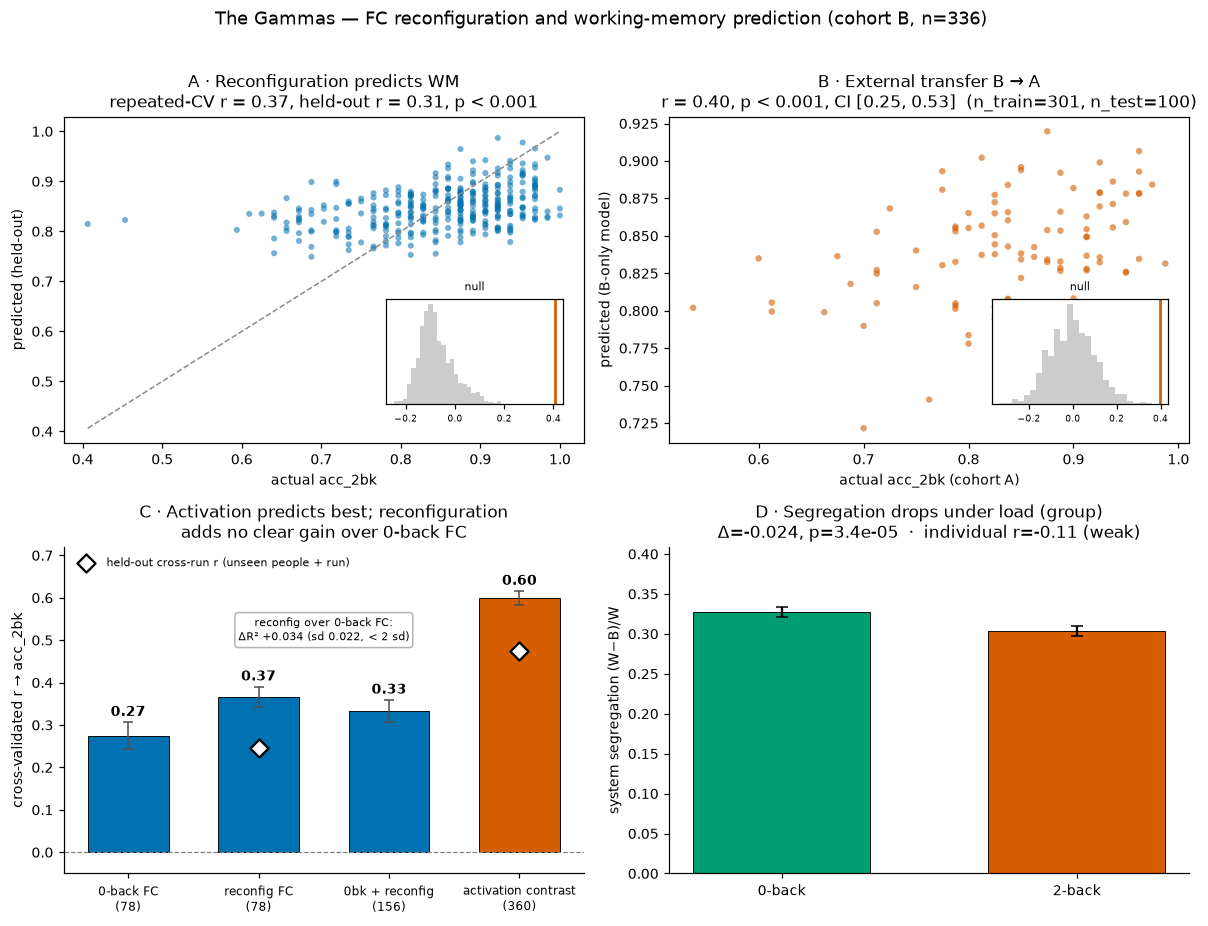

In [12]:
OKA_BLUE, OKA_ORANGE, OKA_GREEN, GREY = "#0072B2", "#D55E00", "#009E73", "#8a8a8a"

def p_text(p):                                       # derived p label; never a typed literal
    floor = 1 / (N_PERM + 1)
    return f"p < {floor:.3f}" if p <= floor + 1e-12 else f"p = {p:.3f}"

fig, axes = plt.subplots(2, 2, figsize=(11, 8.4))
axA, axB, axC, axD = axes.ravel()

# (A) main prediction: predicted vs actual + null inset
axA.scatter(y, pred_recon, s=16, alpha=0.55, color=OKA_BLUE, edgecolor="none")
lims = [min(y.min(), pred_recon.min()), max(y.max(), pred_recon.max())]
axA.plot(lims, lims, ls="--", lw=1, color=GREY)
axA.set(xlabel="actual acc_2bk", ylabel="predicted (held-out)",
        title=f"A · Reconfiguration predicts WM\nrepeated-CV r = {r_recon_mean:.2f}, "
              f"held-out r = {r_heldout:.2f}, {p_text(p_recon)}")
ins = axA.inset_axes([0.62, 0.12, 0.34, 0.32])
ins.hist(null_recon, bins=25, color="0.8"); ins.axvline(r_seed42, color=OKA_ORANGE, lw=1.8)
ins.set_title("null", fontsize=7); ins.tick_params(labelsize=6); ins.set_yticks([])

# (B) external transfer
axB.scatter(yA, pred_A, s=18, alpha=0.6, color=OKA_ORANGE, edgecolor="none")
axB.set(xlabel="actual acc_2bk (cohort A)", ylabel="predicted (B-only model)",
        title=f"B · External transfer B → A\nr = {r_ext:.2f}, {p_text(p_ext)}, "
              f"CI [{ci_ext[0]:.2f}, {ci_ext[1]:.2f}]  "
              f"(n_train={res['transfer']['n_train']}, n_test={res['transfer']['n_test']})")
ins2 = axB.inset_axes([0.62, 0.12, 0.34, 0.32])
ins2.hist(null_ext, bins=25, color="0.8"); ins2.axvline(r_ext, color=OKA_ORANGE, lw=1.8)
ins2.set_title("null", fontsize=7); ins2.tick_params(labelsize=6); ins2.set_yticks([])

# (C) method comparison bars + held-out cross-run diamonds
names = [n for n, _ in panel]
bars = np.array([r_methods[n][0] for n in names])
sds = np.array([r_methods[n][1] for n in names])
cols = [OKA_BLUE, OKA_BLUE, OKA_BLUE, OKA_ORANGE]
xpos = np.arange(len(names))
axC.bar(xpos, bars, yerr=sds, capsize=3, color=cols, edgecolor="black", lw=0.6, width=0.62,
        error_kw=dict(ecolor="0.3", lw=1))
for xi, r, sd in zip(xpos, bars, sds):
    axC.text(xi, r + sd + 0.015, f"{r:.2f}", ha="center", fontsize=9, fontweight="bold")
held = {1: xr_recon, 3: xr_act}
axC.scatter(list(held), [held[i] for i in held], marker="D", s=70, color="white",
            edgecolor="black", lw=1.5, zorder=5, label="held-out cross-run r (unseen people + run)")
axC.axhline(0, color="0.5", lw=0.8, ls="--")
axC.text(1.5, 0.50, f"reconfig over 0-back FC:\nΔR² {d_recon:+.3f} (sd {s_recon:.3f}, < 2 sd)",
         ha="center", fontsize=7.5, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.7"))
axC.set_xticks(xpos); axC.set_xticklabels([n.replace(" (", "\n(") for n in names], fontsize=8)
axC.set(ylabel="cross-validated r → acc_2bk", ylim=(-0.05, 0.72),
        title="C · Activation predicts best; reconfiguration\nadds no clear gain over 0-back FC")
axC.legend(loc="upper left", fontsize=7.5, frameon=False)
axC.spines[["top", "right"]].set_visible(False)

# (D) segregation: group drop + individual link
axD.bar([0, 1], [seg0.mean(), seg2.mean()],
        yerr=[seg0.std()/np.sqrt(len(seg0)), seg2.std()/np.sqrt(len(seg2))],
        capsize=4, color=[OKA_GREEN, OKA_ORANGE], edgecolor="black", lw=0.6, width=0.6)
axD.set_xticks([0, 1]); axD.set_xticklabels(["0-back", "2-back"])
axD.set(ylabel="system segregation (W−B)/W",
        title=f"D · Segregation drops under load (group)\nΔ={dseg.mean():.3f}, p={p_seg:.1e}  ·  "
              f"individual r={r_dseg:.2f} (weak)")
axD.set_ylim(0, max(seg0.mean(), seg2.mean()) * 1.25)
axD.spines[["top", "right"]].set_visible(False)

fig.suptitle("The Gammas — FC reconfiguration and working-memory prediction (cohort B, n=336)",
             fontsize=12, y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.98])
FIG_PATH = "02_canonical_figure.png"
fig.savefig(FIG_PATH, dpi=150, bbox_inches="tight")
print("saved", FIG_PATH)
# figure auto-renders inline as display_data at cell end (inline-backend behaviour)

## 9B · Where load reconfigures cortical coupling (anatomy, for slides)

A second aggregate figure that gives the reconfiguration quantity an **anatomical form** — the visual
Kerem/Goutham asked for on the map, built from the *same* group-mean FC that underlies the fingerprint,
with no new metric:

- **(A)** the 12×12 **network reconfiguration matrix** — group-mean ΔFC (2-back − 0-back) per
  within/between-network block. This is literally the 78-feature fingerprint laid out as a grid
  (12 within-diagonal + 66 off-diagonal cells); the strongest within-network drop is boxed.
- **(B)** the same change projected onto the cortex — per-ROI mean coupling change at the real Glasser
  MNI centroids (`hcp_atlas_339.npz`), rendered as a static glass brain.

**Read this as description, not prediction.** It shows *where*, on average, coupling reorganises under
load — it is a group-mean map, not a per-region importance or a per-subject predictor. Our predictive
result is the **multivariate pattern** (§5); the scalar/regional summaries of this same change are weak
individually (§4, §8). Kept in scope: no clustering, tangent FC, or new graph metric — only the ΔFC
already computed above.

group-mean ΔFC range -0.184..+0.147 | strongest within-network drop: Language (-0.048)
saved 02_canonical_figure2.png


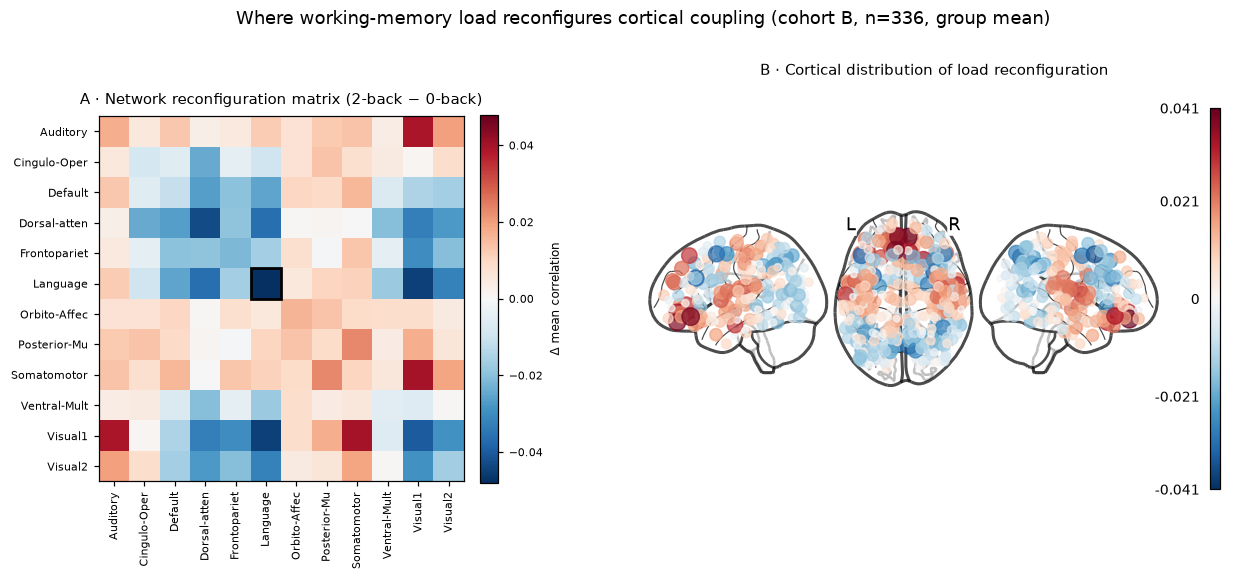

In [13]:
# group-mean FC per condition was accumulated inside extract(); no reload, no per-subject storage.
net_fig = featB["net"]
societies = np.unique(net_fig)                        # alphabetical, matches network_fingerprint order
coords = np.load(B.atlas, allow_pickle=True)["coords"]        # real Glasser MNI centroids (360, 3)
dFC = featB["FC2_group"] - featB["FC0_group"]                 # group-mean reconfiguration (360, 360)

K = len(societies)
idx = [np.where(net_fig == s)[0] for s in societies]
M = np.zeros((K, K))                                  # 12x12 network reconfiguration blocks
for a in range(K):
    for b in range(K):
        block = dFC[np.ix_(idx[a], idx[b])]
        M[a, b] = block[np.triu_indices(len(idx[a]), k=1)].mean() if a == b else block.mean()
off = dFC.copy(); np.fill_diagonal(off, np.nan)
roi_recon = np.nanmean(off, axis=1)                   # per-ROI mean coupling change (360,)
j = int(np.argmin(np.diag(M)))                        # strongest within-network drop (derived)
print(f"group-mean ΔFC range {dFC.min():+.3f}..{dFC.max():+.3f} | "
      f"strongest within-network drop: {societies[j]} ({np.diag(M)[j]:+.3f})")

short = [s[:12] for s in societies]
fig2 = plt.figure(figsize=(13.2, 5.0))
gs = fig2.add_gridspec(1, 2, width_ratios=[1.0, 1.45], wspace=0.30)

axM = fig2.add_subplot(gs[0, 0])
vmax = np.abs(M).max()
im = axM.imshow(M, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
axM.set_xticks(range(K)); axM.set_xticklabels(short, rotation=90, fontsize=7)
axM.set_yticks(range(K)); axM.set_yticklabels(short, fontsize=7)
axM.set_title("A · Network reconfiguration matrix (2-back − 0-back)", fontsize=10, pad=8)
axM.add_patch(plt.Rectangle((j - 0.5, j - 0.5), 1, 1, fill=False, ec="black", lw=1.8))
cb = fig2.colorbar(im, ax=axM, fraction=0.046, pad=0.04); cb.ax.tick_params(labelsize=7)
cb.set_label("Δ mean correlation", fontsize=8)

axB = fig2.add_subplot(gs[0, 1])
rmax = np.abs(roi_recon).max()
plotting.plot_markers(
    roi_recon, coords, node_size=16 + 120 * (np.abs(roi_recon) / rmax),
    node_cmap="RdBu_r", node_vmin=-rmax, node_vmax=rmax,
    display_mode="lzr", axes=axB, colorbar=True, title=None)
axB.set_title("B · Cortical distribution of load reconfiguration", fontsize=10, pad=8)

fig2.suptitle(f"Where working-memory load reconfigures cortical coupling "
              f"(cohort B, n={featB['n']}, group mean)", fontsize=11.5, y=1.02)
FIG2_PATH = "02_canonical_figure2.png"
fig2.savefig(FIG2_PATH, dpi=150, bbox_inches="tight")
print("saved", FIG2_PATH)
# figure auto-renders inline as display_data at cell end

## 10 · Abstract alignment — the official (corrected) text and the submitted record

Two versions of the abstract live in [`manuscript/abstract.md`](../manuscript/abstract.md):

- the **submitted** version (20 Jul, sent via Airtable/PDF) — a **closed historical record**. NMA does
  not grade the abstract, so it was not resubmitted; it stays on file exactly as sent.
- the **corrected 21 Jul draft** — the **official text we use for the W3D5 presentation**. It is the
  version aligned with this notebook, and its numbers and closing match what is computed here.

The corrected draft was not a free rewrite: three submitted numbers came from Goutham's Colab and were
not reproducible from the repo. nb09 ran his functions **verbatim on our data layer** and traced each
difference to his **data loading**, not his method. We use the methodologically correct value and
record the difference below — no number is silently overwritten. The *submitted* figures are fixed
history; the *canonical* figures are **derived from `res`** in the cell that follows, so this record
cannot drift from the computation.

| Claim (submitted 20 Jul) | Corrected in official text | Origin of the difference |
|---|---|---|
| fingerprint **r ≈ 0.35, p < 0.0001** | **r ≈ 0.37, p < 0.001** | committed 0.2376 was a data-loading artifact (raw-bundle EV handling); method sound → §5 |
| condition-specific **r ≈ 0.28** | unchanged, protocol named | ambiguous token: 0-back-alone FC (0.274) vs undifferenced whole-task FC (0.278) → §7 |
| **ΔSegregation = −0.048, p < 0.005** | present **qualitatively** (direction) | direction reproduces (paired-t p ≈ 3e-05); magnitude ≈ half (atlas/edge conventions) → §8 |
| *"complementary information beyond static FC"* | **dropped**, honest closing added | never tested pre-submission; nested test does not support it (incremental < 2 sd) → §7 |

**The official closing — and it is exactly what this notebook shows.** The corrected abstract ends
(quoted verbatim; a real-but-not-connectivity-specific reading, no causal claim):

> These findings show that individual working-memory performance can be predicted from distributed
> within- and between-network connectivity, and that global network organization shifts from
> segregation toward integration under higher load. Load reconfiguration, however, did not clearly add
> predictive information beyond single-condition (0-back) connectivity, and a simpler task-activation
> contrast predicted performance at least as well (r ≈ 0.60). Load reconfiguration may therefore be a
> real but not connectivity-specific predictor of working-memory ability; the observational,
> single-task design does not support causal claims.

Every clause maps to a section here: prediction in unseen subjects → §5–§6; segregation → integration
under load → §8 and §9B; "no clear gain over 0-back FC" and "activation predicts ≥ as well (r ≈ 0.60)"
→ §7; the causal caveat → the limitation column of §11.

**FCM / clustering, tangent FC, new graph metrics are out of the main analysis.** FCM on the group ΔFC
is weak and near-maximum-entropy (K-Means silhouette ≈ 0.15, FCM entropy ≈ 1.32 vs ln 4 = 1.39,
[nb09](../sandbox/jaime/09_goutham_pipeline_replication.ipynb)); it is exploratory/visual only, not a
result, and is not recomputed here.

In [14]:
# Submitted abstract values are fixed historical constants (what we submitted on 20 Jul);
# canonical values are pulled from `res` so the reconciliation is derived, not re-typed.
SUBMITTED = {"fingerprint r": 0.35, "condition-specific r": 0.28, "dSegregation": -0.048}
discrepancy = pd.DataFrame([
    dict(quantity="fingerprint r (main prediction)", submitted=SUBMITTED["fingerprint r"],
         canonical=round(res["reconfig_acc"]["r_repcv"], 3),
         note="submitted from a data-loading artifact (committed 0.2376); method sound"),
    dict(quantity="condition-specific r (0-back FC)", submitted=SUBMITTED["condition-specific r"],
         canonical=round(res["methods"]["0-back FC (78)"], 3),
         note="0-back-alone FC by protocol (submitted token was ambiguous)"),
    dict(quantity="ΔSegregation (group)", submitted=SUBMITTED["dSegregation"],
         canonical=round(res["segregation"]["dseg"], 3),
         note="same sign; magnitude ~half; present qualitatively"),
])
discrepancy["delta"] = (discrepancy["canonical"] - discrepancy["submitted"]).round(3)
discrepancy

Out[14]: 
                           quantity  ...  delta
0   fingerprint r (main prediction)  ...  0.016
1  condition-specific r (0-back FC)  ... -0.006
2              ΔSegregation (group)  ...  0.024

[3 rows x 5 columns]


,quantity,submitted,canonical,note,delta
0,fingerprint r (main prediction),0.350,0.366,submitted from a data-loading artifact (commit...,0.016
1,condition-specific r (0-back FC),0.280,0.274,0-back-alone FC by protocol (submitted token w...,-0.006
2,ΔSegregation (group),-0.048,-0.024,same sign; magnitude ~half; present qualitatively,0.024


## 11 · Claim → result → figure → limitation

Built from the `res` dict computed above (numbers derived, never typed). This is the map from each
presentation claim to its evidence and its caveat.

In [15]:
def fmt_incr(t): return f"ΔR²={t[0]:+.3f} (sd {t[1]:.3f})"

summary = pd.DataFrame([
    dict(claim="Reconfiguration FC predicts WM in unseen subjects",
         result=f"repeated-CV r={res['reconfig_acc']['r_repcv']:.3f}±{res['reconfig_acc']['sd']:.3f}, "
                f"held-out {res['reconfig_acc']['r_heldout']:.2f}, p<0.001",
         figure="9A", limitation="Same-task, associational; attenuates to "
                f"partial r={res['reconfig_acc']['partial_acc0']:.2f} controlling acc_0bk"),
    dict(claim="d′ retains signal under the ability control",
         result=f"repeated-CV r={res['reconfig_dprime']['r_repcv']:.3f}, "
                f"partial|acc_0bk {res['reconfig_dprime']['partial_acc0']:.2f}",
         figure="—", limitation="B-only (A has no usable false-alarm rate)"),
    dict(claim="Model transfers to an independent cohort (B→A)",
         result=f"r={res['transfer']['r']:.3f}, p<0.001, CI[{res['transfer']['ci'][0]:.2f},"
                f"{res['transfer']['ci'][1]:.2f}], train {res['transfer']['n_train']}/test {res['transfer']['n_test']}",
         figure="9B", limitation=f"Sibling HCP cohorts ({res['transfer']['shared']} shared removed); "
                "acc_2bk only; kinship unmodelled"),
    dict(claim="Reconfiguration adds no clear gain over 0-back FC",
         result=fmt_incr(res['incremental']['recon_over_0bk']) + " (< 2 sd)",
         figure="9C", limitation="Heuristic (2 sd), not a formal test"),
    dict(claim="Regional activation predicts better; FC not specific",
         result=f"activation r={res['activation']['r']:.2f} vs reconfig "
                f"{res['methods']['reconfig FC (78)']:.2f}; FC over activation "
                f"{fmt_incr(res['incremental']['fc_over_act'])}",
         figure="9C", limitation="Not count-matched (360 vs 78); one collinear activation axis"),
    dict(claim="Activation robust to ability & motion",
         result=f"partial|acc_0bk {res['activation']['partial_acc0']:.2f}, "
                f"partial|DVARS {res['activation']['partial_dvars']:.2f}, p<0.001",
         figure="—", limitation="Controls do not prove 'no artifact'"),
    dict(claim="Segregation drops under load (group direction)",
         result=f"Δ={res['segregation']['dseg']:.3f}, paired p={res['segregation']['p_group']:.1e}",
         figure="9D", limitation=f"Individual link weak (r={res['segregation']['r_indiv']:.2f}); "
                "magnitude ≠ abstract's −0.048"),
], columns=["claim", "result", "figure", "limitation"])
pd.set_option("display.max_colwidth", 60)
summary

Out[15]: 
                                                  claim  ...                                                   limitation
0     Reconfiguration FC predicts WM in unseen subjects  ...  Same-task, associational; attenuates to partial r=0.22 c...
1           d′ retains signal under the ability control  ...                    B-only (A has no usable false-alarm rate)
2        Model transfers to an independent cohort (B→A)  ...  Sibling HCP cohorts (35 shared removed); acc_2bk only; k...
3     Reconfiguration adds no clear gain over 0-back FC  ...                          Heuristic (2 sd), not a formal test
4  Regional activation predicts better; FC not specific  ...  Not count-matched (360 vs 78); one collinear activation ...
5                 Activation robust to ability & motion  ...                          Controls do not prove 'no artifact'
6        Segregation drops under load (group direction)  ...  Individual link weak (r=-0.11); magnitude ≠ abstract's −...

[7 rows x 4 c

,claim,result,figure,limitation
0,Reconfiguration FC predicts WM in unseen subjects,"repeated-CV r=0.366±0.024, held-out 0.31, p<0.001",9A,"Same-task, associational; attenuates to partial r=0.22 c..."
1,d′ retains signal under the ability control,"repeated-CV r=0.352, partial|acc_0bk 0.25",—,B-only (A has no usable false-alarm rate)
2,Model transfers to an independent cohort (B→A),"r=0.398, p<0.001, CI[0.25,0.53], train 301/test 100",9B,Sibling HCP cohorts (35 shared removed); acc_2bk only; k...
3,Reconfiguration adds no clear gain over 0-back FC,ΔR²=+0.034 (sd 0.022) (< 2 sd),9C,"Heuristic (2 sd), not a formal test"
4,Regional activation predicts better; FC not specific,activation r=0.60 vs reconfig 0.37; FC over activation Δ...,9C,Not count-matched (360 vs 78); one collinear activation ...
5,Activation robust to ability & motion,"partial|acc_0bk 0.41, partial|DVARS 0.58, p<0.001",—,Controls do not prove 'no artifact'
6,Segregation drops under load (group direction),"Δ=-0.024, paired p=3.4e-05",9D,Individual link weak (r=-0.11); magnitude ≠ abstract's −...


## 12 · Environment and run time

Recorded for reproducibility: package versions and total wall-clock from the setup cell.

In [16]:
import numpy, scipy, sklearn, pandas as _pd, matplotlib
versions = {"python": platform.python_version(), "numpy": numpy.__version__,
            "scipy": scipy.__version__, "scikit-learn": sklearn.__version__,
            "pandas": _pd.__version__, "matplotlib": matplotlib.__version__}
print("environment:", " · ".join(f"{k} {v}" for k, v in versions.items()))
print(f"N_PERM = {N_PERM} · N_SEEDS = {N_SEEDS} · seed = {SEED}")
print(f"total run time: {time.time() - T_START:.0f} s")

environment: python 3.12.13 · numpy 2.5.1 · scipy 1.18.0 · scikit-learn 1.9.0 · pandas 3.0.3 · matplotlib 3.11.0
N_PERM = 1000 · N_SEEDS = 20 · seed = 42
total run time: 312 s
